In [1]:
%%capture
%run pre_processing2.ipynb


## Why DenseNet121?

DenseNet121 was selected for this experiment due to its ability to enhance feature propagation and encourage feature reuse through dense connectivity between layers. Unlike traditional convolutional networks where each layer receives input only from the previous layer, DenseNet connects each layer to all preceding layers, allowing the network to preserve both low-level and high-level features throughout the model. This design helps alleviate the vanishing gradient problem and improves learning efficiency, particularly when training on relatively small datasets. DenseNet121 has also shown strong performance in medical image analysis tasks, making it a suitable architecture for analyzing ventilator waveform images. Additionally, the availability of pretrained ImageNet weights supports effective transfer learning, enabling the model to learn meaningful visual patterns even with limited training data.

In [2]:
import torch
import torch.nn as nn
from torchvision.models import densenet121, DenseNet121_Weights
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


Load DenseNet121

In [4]:

weights = DenseNet121_Weights.IMAGENET1K_V1
model = densenet121(weights=weights)

In [5]:
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, NUM_CLASSES)

In [6]:
for param in model.features.parameters():
    param.requires_grad = False

In [7]:
model = model.to(device)

Loss + Optimizer + Class Weights

In [18]:

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_id']),
    y=train_df['label_id']
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class Weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Class Weights: tensor([0.8628, 0.8628, 1.1494, 1.1417, 1.1045, 1.1045, 1.0730, 1.0730, 0.8584,
        0.8584, 1.0183, 1.0531])


Train One Epoch Function and Evaluation Function

In [19]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [20]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

Loop training

In [21]:
num_epochs = 15
best_val_acc = 0.0

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch}/{num_epochs}")
    print(f"  Train  -> Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
    print(f"  Val    -> Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_densenet121_weighted.pth")
        print("  ✅ New best model saved!")

Epoch 1/15
  Train  -> Loss: 2.3608, Acc: 0.1922
  Val    -> Loss: 2.1955, Acc: 0.2890
  ✅ New best model saved!
Epoch 2/15
  Train  -> Loss: 2.0775, Acc: 0.3775
  Val    -> Loss: 1.9737, Acc: 0.4243
  ✅ New best model saved!
Epoch 3/15
  Train  -> Loss: 1.8718, Acc: 0.4829
  Val    -> Loss: 1.7794, Acc: 0.5149
  ✅ New best model saved!
Epoch 4/15
  Train  -> Loss: 1.7244, Acc: 0.5353
  Val    -> Loss: 1.6571, Acc: 0.5436
  ✅ New best model saved!
Epoch 5/15
  Train  -> Loss: 1.6018, Acc: 0.5709
  Val    -> Loss: 1.5505, Acc: 0.5768
  ✅ New best model saved!
Epoch 6/15
  Train  -> Loss: 1.5156, Acc: 0.5881
  Val    -> Loss: 1.4631, Acc: 0.6319
  ✅ New best model saved!
Epoch 7/15
  Train  -> Loss: 1.4332, Acc: 0.6223
  Val    -> Loss: 1.4153, Acc: 0.6250
Epoch 8/15
  Train  -> Loss: 1.3694, Acc: 0.6319
  Val    -> Loss: 1.3555, Acc: 0.6433
  ✅ New best model saved!
Epoch 9/15
  Train  -> Loss: 1.3192, Acc: 0.6279
  Val    -> Loss: 1.3065, Acc: 0.6548
  ✅ New best model saved!
Epoch 10/

The training logs show steady improvement in both training and validation performance across epochs. Validation accuracy gradually increased and reached its best value in the final epoch, although the overall performance remained moderate.

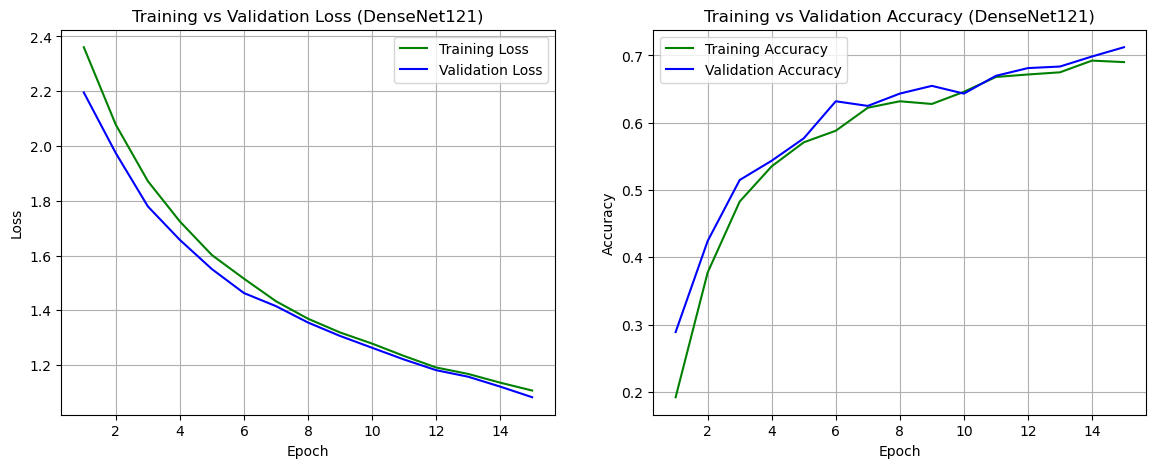

In [22]:
train_losses = [
2.3608, 2.0775, 1.8718, 1.7244, 1.6018,
1.5156, 1.4332, 1.3694, 1.3192, 1.2786,
1.2333, 1.1913, 1.1678, 1.1359, 1.1071
]

val_losses = [
2.1955, 1.9737, 1.7794, 1.6571, 1.5505,
1.4631, 1.4153, 1.3555, 1.3065, 1.2633,
1.2204, 1.1815, 1.1576, 1.1215, 1.0827
]

train_accuracies = [
0.1922, 0.3775, 0.4829, 0.5353, 0.5709,
0.5881, 0.6223, 0.6319, 0.6279, 0.6459,
0.6680, 0.6717, 0.6749, 0.6923, 0.6901
]

val_accuracies = [
0.2890, 0.4243, 0.5149, 0.5436, 0.5768,
0.6319, 0.6250, 0.6433, 0.6548, 0.6433,
0.6697, 0.6812, 0.6835, 0.6984, 0.7122
]


import matplotlib.pyplot as plt
import seaborn as sns

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Training Loss', color='green')
plt.plot(epochs, val_losses, label='Validation Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (DenseNet121)')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Training Accuracy', color='green')
plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy (DenseNet121)')
plt.legend()
plt.grid(True)

plt.show()

As the figure shows, training and validation loss decrease steadily over the epochs, while both training and validation accuracy gradually increase. This indicates that the model is learning effectively from the data and improving its performance in a stable manner.

Evaluation on Test Set

In [23]:
best_model = model
state_dict = torch.load("best_densenet121_weighted.pth", map_location=device)
best_model.load_state_dict(state_dict)
best_model.to(device)

test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 1.0933
Test Accuracy: 0.6942


In [8]:
from sklearn.metrics import classification_report

best_model = model
state_dict = torch.load("best_densenet121_weighted.pth", map_location=device)
best_model.load_state_dict(state_dict)
best_model.to(device)
best_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = best_model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.62      0.70        85
           1       0.72      0.85      0.78        85
           2       0.57      0.60      0.58        63
           3       0.68      0.67      0.67        63
           4       0.66      0.88      0.75        65
           5       0.78      0.72      0.75        65
           6       0.65      0.76      0.70        68
           7       0.75      0.94      0.84        68
           8       0.73      0.58      0.64        85
           9       0.72      0.78      0.75        85
          10       0.64      0.49      0.55        72
          11       0.61      0.45      0.52        69

    accuracy                           0.69       873
   macro avg       0.69      0.69      0.69       873
weighted avg       0.69      0.69      0.69       873



**Summary:**

The classification report indicates moderate performance with a macro F1-score of about 0.69. Although the model successfully identifies several waveform classes, prediction performance varies across categories.

In [25]:
from sklearn.metrics import confusion_matrix

true_labels = []
predicted_labels = []

best_model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model(images)
        _, preds = torch.max(outputs, 1)

        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(preds.cpu().numpy())

cm = confusion_matrix(true_labels, predicted_labels)

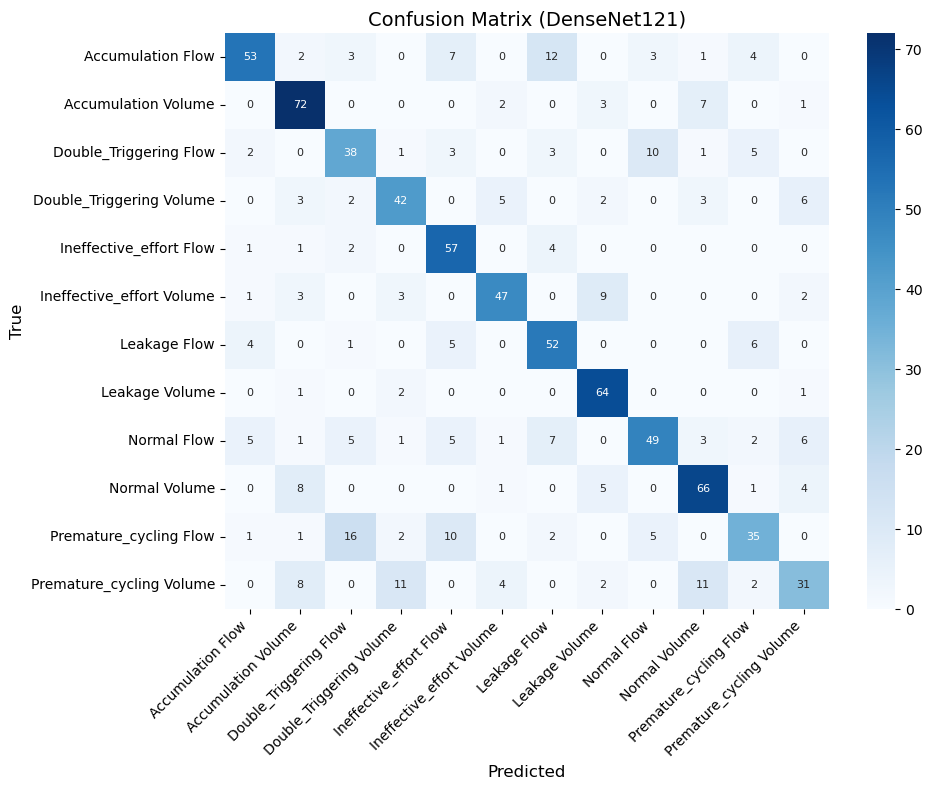

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    annot_kws={"size": 8}
)

plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.title("Confusion Matrix (DenseNet121)", fontsize=14)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**Observation & Conclusion:** 

The confusion matrix shows that DenseNet121 correctly predicts several waveform classes, as reflected by the values along the diagonal. However, noticeable misclassifications appear between certain classes. This indicates that while the model captures some important features, it still faces challenges in clearly distinguishing between specific waveform categories.

In [9]:
import numpy as np

print("\nTrue Class Accuracy for each Class:\n")

all_labels_np = np.array(all_labels)
all_preds_np = np.array(all_preds)

for i, class_name in enumerate(CLASSES):

    TP = np.sum((all_labels_np == i) & (all_preds_np == i))
    TN = np.sum((all_labels_np != i) & (all_preds_np != i))
    FP = np.sum((all_labels_np != i) & (all_preds_np == i))
    FN = np.sum((all_labels_np == i) & (all_preds_np != i))

    class_accuracy = (TP + TN) / (TP + TN + FP + FN)

    print(f"{class_name}: {class_accuracy:.4f}")


True Class Accuracy for each Class:

Accumulation Flow: 0.9473
Accumulation Volume: 0.9530
Double_Triggering Flow: 0.9381
Double_Triggering Volume: 0.9530
Ineffective_effort Flow: 0.9565
Ineffective_effort Volume: 0.9645
Leakage Flow: 0.9496
Leakage Volume: 0.9714
Normal Flow: 0.9381
Normal Volume: 0.9485
Premature_cycling Flow: 0.9347
Premature_cycling Volume: 0.9336
